# Visual Analytics - Melanoma Classification

## Imports

In [1]:
# python modules
import numpy as np
import pandas as pd
import seaborn as snb
import matplotlib as mlt

In [78]:
# custom modules
from utils.get_data import get_data
from utils.plots.histogramm import plot_hist
from utils.image_helpers import get_means_and_stds
from utils.plots.image_histogramm import image_hist
from utils.plots.show_image import show_single_image, show_images

## Globals

In [12]:
IMG_DIR = "data/"

In [5]:
# automatic reload magic
%load_ext autoreload
%autoreload 2

Get the csv files

In [6]:
cancer_index = pd.read_csv("data/Index-Hautkrebsanfaelligkeit.csv", sep=";")
cancer_index_so = pd.read_csv("data/Sozio-oekonomischer-Hautkrebsindex.csv", sep=";")

In [13]:
test_df = get_data("data/test.csv", "test", IMG_DIR)
train_df = get_data("data/train.csv", "train", IMG_DIR)

valid rows 10982
valid rows 20451


Display the dataframes

In [29]:
cancer_index.head(3)

,Land,Region,Hautkrebs-Inzidenz,Melanom Erkrankungen pro Jahr,UV-Intensität (ø),Hattyp (ø)
0,Neuseeland,Australia,10,2473,"6,88","4,75"
1,Australien,Australia,"9,67",12265,"7,35","5,75"
2,Schweiz,Europe,"5,89",2484,"2,8","7,75"


In [30]:
cancer_index_so = cancer_index_so[['Land', 'Sterblichkeitsrate', 'Ungleichheit der Lebenserwartung', 'Nationale Gesundheitsausgaben', 'Gesamtwertung']]
cancer_index_so.head(3)

,Land,Sterblichkeitsrate,Ungleichheit der Lebenserwartung,Nationale Gesundheitsausgaben,Gesamtwertung
0,Schweden,17.00%,"3,11","4,20",8.4
1,Schweiz,15.00%,"3,92","2,81",8.4
2,Italien,14.00%,"3,35","6,32",8.9


In [32]:
# combine both dataframes into one
df_cancer_index = cancer_index.merge(cancer_index_so, how="inner", on='Land')
df_cancer_index.head(12)

,Land,Region,Hautkrebs-Inzidenz,Melanom Erkrankungen pro Jahr,UV-Intensität (ø),Hattyp (ø),Sterblichkeitsrate,Ungleichheit der Lebenserwartung,Nationale Gesundheitsausgaben,Gesamtwertung
0,Neuseeland,Australia,10,2473,"6,88","4,75",15.00%,"4,77","5,19",10.3
1,Australien,Australia,"9,67",12265,"7,35","5,75",13.00%,"4,21","4,98",9.3
2,Schweiz,Europe,"5,89",2484,"2,8","7,75",15.00%,"3,92","2,81",8.4
3,Schweden,Europe,"5,79",2911,"1,28","9,75",17.00%,"3,11","4,20",8.4
4,Norwegen,Europe,"5,71",1506,1,10,22.00%,"3,36","3,44",9.3
5,Niederlande,Europe,"5,6",4804,"2,42","8,75",18.00%,"3,87","4,76",9.7
6,Dänemark,Europe,"5,57",1596,"2,23","8,25",14.00%,"3,96","4,28",9.0
7,USA,North America,"4,62",72000,"4,98",6,14.00%,"6,19","1,20",10.9
8,Großbritannien,Europe,"4,6",14445,"2,33","9,25",15.00%,"4,48","6,14",10.3
9,Finnland,Europe,"4,59",1208,"1,19","9,5",18.00%,"3,53","5,82",9.4


### Erklärung der Daten

- Hautkrebs-Inzidenz: Anzahl neuer Hautkrebsfälle pro Jahr, gemessen an der Bevölkerung (skaliert von 1-10).
- Durchschnittliche UV-Intensität: Der Wert gibt an wie stark die UV-Strahlung im Jahresdurchschnitt in den einzelnen Ländern ist (skaliert von 1-10, größer = stärkere Strahlung).
- Durchschnittlicher Hauttyp: Basierend auf der Fitzpatrick-Skala, gibt dieser Wert an, wie stark Pigmentiert die Bevölkerung im Durchschnitt ist (skaliert von 1-10, größer = hellere Haut und somit anfälliger für Hautkrebs).
- Sozioökonomischer Index: In diesem Teil gilt für alle Zahlen, dass eine kleinere Zahl einen höheren Behandlungsstandard repräsentiert (kleiner = besser).
- Nationale Gesundheitsausgaben: Umso kleiner die Zahl, umso mehr geben die Länder für das Gesundheitssystem aus (skaliert von 1-10, kleiner = mehr).
- Ungleichheit der Lebenserwartung(%): Daten basierend auf Human Development Index. Zeigt die Korrealtion von Lebenserwartung und Einkommen in den verschiedenen Ländern.

Source: https://derma.plus/hautkrebs-index-2018 & https://derma.plus/globaler-hautkrebs-index

In [50]:
train_df.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target,image_path
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0,data/train/ISIC_2637011.png
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0,data/train/ISIC_0015719.png
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0,data/train/ISIC_0052212.png
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0,data/train/ISIC_0068279.png
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0,data/train/ISIC_0074268.png


In [17]:
test_df.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,image_path
0,ISIC_0052060,IP_3579794,male,70.0,NaN,data/test/ISIC_0052060.png
1,ISIC_0052349,IP_7782715,male,40.0,lower extremity,data/test/ISIC_0052349.png
2,ISIC_0058510,IP_7960270,female,55.0,torso,data/test/ISIC_0058510.png
3,ISIC_0073313,IP_6375035,female,50.0,torso,data/test/ISIC_0073313.png
4,ISIC_0073502,IP_0589375,female,45.0,lower extremity,data/test/ISIC_0073502.png


## Analyse der Bilder

Wie lässt sich ein Bild analyiseren?

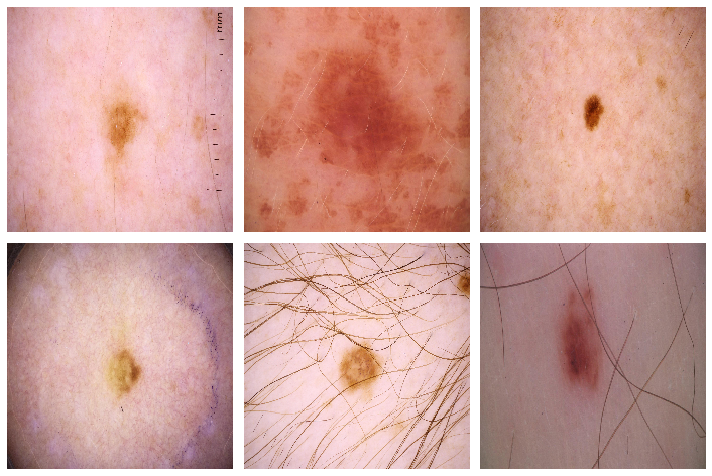

In [33]:
# Display 9 random images from the train df
imgs = list(train_df.sample(9).image_path)
show_images(imgs, 3, 2)

image_name                                      ISIC_2637011
patient_id                                        IP_7279968
sex                                                     male
age_approx                                                45
anatom_site_general_challenge                      head/neck
diagnosis                                            unknown
benign_malignant                                      benign
target                                                     0
image_path                       data/train/ISIC_2637011.png
Name: 0, dtype: object
 
Image dimensions:  (224, 224)
Maximum pixel value : 1.0 ; Minimum pixel value:0.0
Mean value of the pixels : 0.7 ; Standard deviation : 0.2


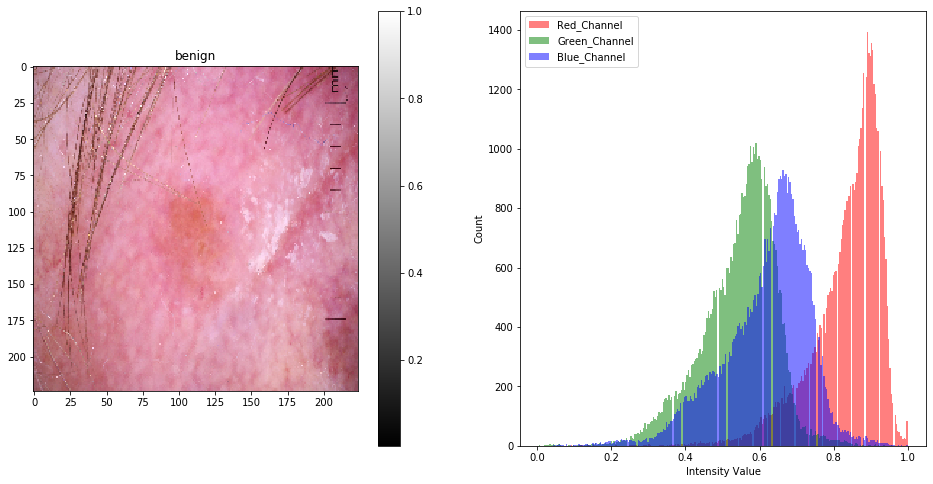

In [42]:
print(train_df.iloc[0])
print(" ")
image_hist(train_df.iloc[0].image_path, train_df.iloc[0].benign_malignant)

image_name                                      ISIC_6220625
patient_id                                        IP_7373371
sex                                                   female
age_approx                                                55
anatom_site_general_challenge                upper extremity
diagnosis                                           melanoma
benign_malignant                                   malignant
target                                                     1
image_path                       data/train/ISIC_6220625.png
Name: 20438, dtype: object
 
Image dimensions:  (224, 224)
Maximum pixel value : 1.0 ; Minimum pixel value:0.1
Mean value of the pixels : 0.6 ; Standard deviation : 0.1


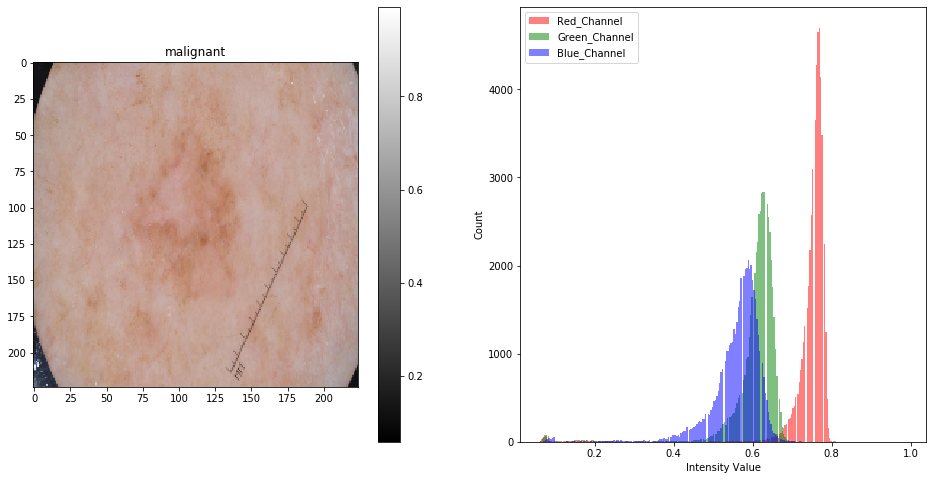

In [49]:
print(train_df.iloc[20438])
print(" ")
image_hist(train_df.iloc[20438].image_path, train_df.iloc[20438].benign_malignant)

Wie sieht das Histogramm eines durchschnittlichen Bildes im Datensatz aus?

- TODO: Erklären was "Mean value of pixels" und Std in diesem Zusammenhang bedeutet
- Note: Bilder sind bereits normalisiert

In [105]:
# get the mean and std form 1000 images 
means, stds = get_means_and_stds(train_df.head(2500))

100%|██████████| 2500/2500 [01:09<00:00, 35.78it/s]


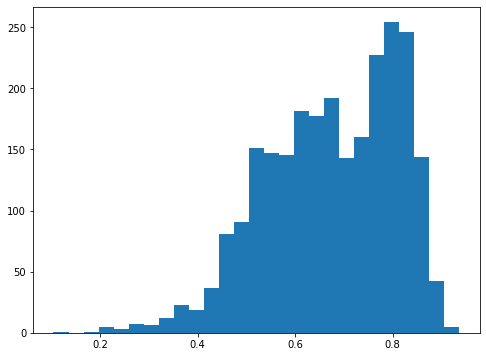

In [106]:
plot_hist(means)

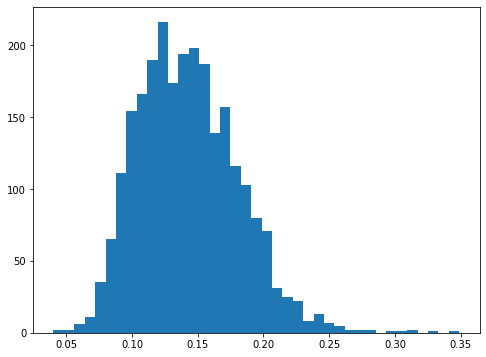

In [107]:
plot_hist(stds)

Calculate the global mean and std

In [108]:
global_mean = np.mean(means)
print("global mean:", global_mean)

global_std = np.mean(stds)
print("global std:", global_std)

global mean: 0.6751815
global std: 0.14290154


Mean and std of malignant cases

In [112]:
malignant = train_df['benign_malignant']=='malignant'
benign = train_df['benign_malignant']=='benign'

malignant_df = train_df[malignant]
malignant_means, malignant_stds = get_means_and_stds(malignant_df.head(2500))

benign_df = train_df[benign]
benign_means, benign_stds = get_means_and_stds(benign_df.head(2500))

print("")

global_malignant_mean = np.mean(malignant_means)
print("global malignant mean:", global_malignant_mean)

global_benign_mean = np.mean(benign_means)
print("global benign mean:", global_benign_mean)

100%|██████████| 2500/2500 [00:08<00:00, 278.13it/s]
global malignant mean: 0.5686471
global benign mean: 0.67643493



Histogramm eines durchschnittlichen Bildes einer gutartigen Läsion aus

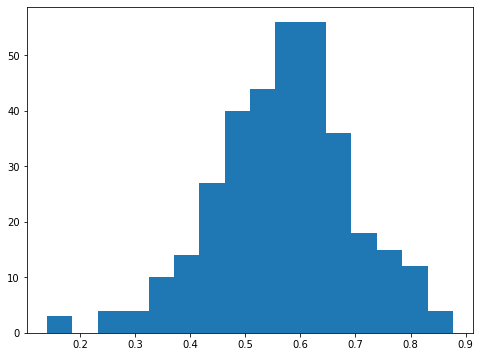

In [110]:
plot_hist(malignant_means)

Histogramm eines durchschnittlichen Bildes eines Melanoms

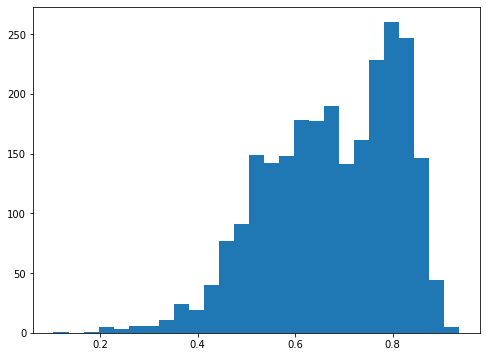

In [111]:
plot_hist(benign_means)

image_name                                      ISIC_2637011
patient_id                                        IP_7279968
sex                                                     male
age_approx                                                45
anatom_site_general_challenge                      head/neck
diagnosis                                            unknown
benign_malignant                                      benign
target                                                     0
image_path                       data/train/ISIC_2637011.png
Name: 0, dtype: object
 
Image dimensions:  (224, 224)
Maximum pixel value : 1.0 ; Minimum pixel value:0.0
Mean value of the pixels : 0.7 ; Standard deviation : 0.2


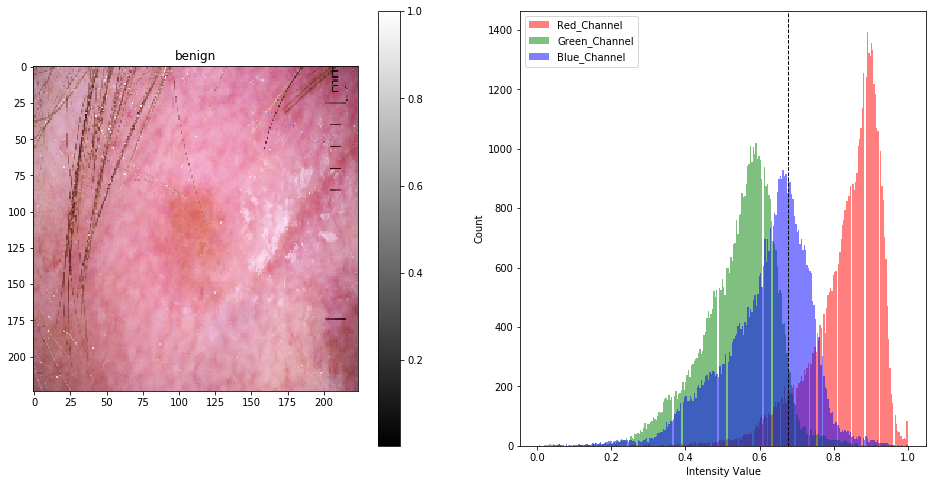

In [115]:
print(train_df.iloc[0])
print(" ")
image_hist(train_df.iloc[0].image_path, train_df.iloc[0].benign_malignant, global_benign_mean)

image_name                                      ISIC_6220625
patient_id                                        IP_7373371
sex                                                   female
age_approx                                                55
anatom_site_general_challenge                upper extremity
diagnosis                                           melanoma
benign_malignant                                   malignant
target                                                     1
image_path                       data/train/ISIC_6220625.png
Name: 20438, dtype: object
 
Image dimensions:  (224, 224)
Maximum pixel value : 1.0 ; Minimum pixel value:0.1
Mean value of the pixels : 0.6 ; Standard deviation : 0.1


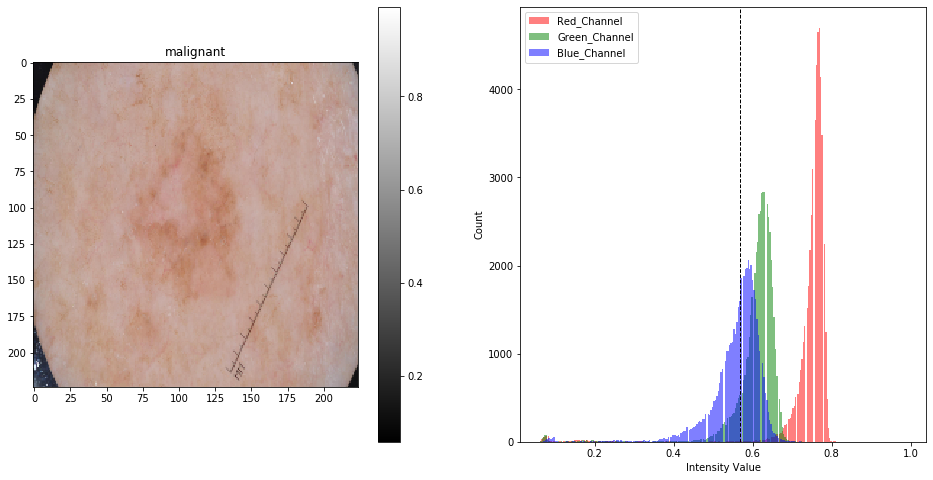

In [116]:
print(train_df.iloc[20438])
print(" ")
image_hist(train_df.iloc[20438].image_path, train_df.iloc[20438].benign_malignant, global_malignant_mean)